**importing** **required** **modules**/**labraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data** **loading**

In [2]:
df=pd.read_csv("/content/liver_cirrhosis.csv")
df.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,2221,C,Placebo,18499,F,N,Y,N,N,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,9.9,1
1,1230,C,Placebo,19724,M,Y,N,Y,N,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,10.8,2
2,4184,C,Placebo,11839,F,N,N,N,N,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,2
3,2090,D,Placebo,16467,F,N,N,N,N,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,10.2,2
4,2105,D,Placebo,21699,F,N,Y,N,N,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,11.5,1


**Understand the structure of Data by basic checks or inspect data**

1. df.info
2. df.shape
3. describe()
4. df.sum()
5. df.duplicated()
6. df.dtypes

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   N_Days         25000 non-null  int64  
 1   Status         25000 non-null  object 
 2   Drug           25000 non-null  object 
 3   Age            25000 non-null  int64  
 4   Sex            25000 non-null  object 
 5   Ascites        25000 non-null  object 
 6   Hepatomegaly   25000 non-null  object 
 7   Spiders        25000 non-null  object 
 8   Edema          25000 non-null  object 
 9   Bilirubin      25000 non-null  float64
 10  Cholesterol    25000 non-null  float64
 11  Albumin        25000 non-null  float64
 12  Copper         25000 non-null  float64
 13  Alk_Phos       25000 non-null  float64
 14  SGOT           25000 non-null  float64
 15  Tryglicerides  25000 non-null  float64
 16  Platelets      25000 non-null  float64
 17  Prothrombin    25000 non-null  float64
 18  Stage 

In [ ]:
df.shape

(25000, 19)

In [ ]:
df.select_dtypes(['int','float']).describe().T

,count,mean,std,min,25%,50%,75%,max
N_Days,25000.0,1887.117040,1091.690918,41.00,1080.00,1680.000000,2576.000000,4795.00
Age,25000.0,18495.877080,3737.596616,9598.00,15694.00,18499.000000,20955.000000,28650.00
Bilirubin,25000.0,3.402644,4.707491,0.30,0.80,1.300000,3.400000,28.00
Cholesterol,25000.0,372.331471,193.668452,120.00,275.00,369.510563,369.510563,1775.00
Albumin,25000.0,3.486578,0.380488,1.96,3.29,3.510000,3.750000,4.64
Copper,25000.0,100.184663,73.184840,4.00,52.00,97.648387,107.000000,588.00
Alk_Phos,25000.0,1995.675597,1798.885660,289.00,1032.00,1828.000000,1982.655769,13862.40
SGOT,25000.0,123.166345,47.747616,26.35,92.00,122.556346,134.850000,457.25
Tryglicerides,25000.0,123.822548,52.786350,33.00,92.00,124.702128,127.000000,598.00
Platelets,25000.0,256.007337,98.679006,62.00,189.00,251.000000,311.000000,721.00


In [ ]:
df.duplicated().sum()

np.int64(15361)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.columns

Index(['N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly',
       'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Stage'],
      dtype='object')

In [ ]:
df.dtypes

,0
N_Days,int64
Status,object
Drug,object
Age,int64
Sex,object
Ascites,object
Hepatomegaly,object
Spiders,object
Edema,object
Bilirubin,float64


**Convert Age (days & Years)**

In [ ]:
df['Age']=round(df['Age']/365)

In [ ]:
df['Age']

,Age
0,51.0
1,54.0
2,32.0
3,45.0
4,59.0
...,...
24963,49.0
24971,64.0
24972,67.0
24991,58.0


**Convert** **N_Days** & **N_Years**

In [ ]:
df['N_Years'] = round(df['N_Days']/365)

In [ ]:
df['N_Years']

,N_Years
0,6.0
1,3.0
2,11.0
3,6.0
4,6.0
...,...
24963,10.0
24971,13.0
24972,9.0
24991,12.0


**Drop_column['N_days']**

In [ ]:
df.drop('N_Days', axis=1, inplace=True)

**Univariate** **Analysis**

* The distribution of numerical features shows that most variables like Bilirubin, SGPT, and SGOT are right-skewed.
* Majority of patients have normal values.
* Few patients have very high values.
* The data is not normally distributed and contains skewness.





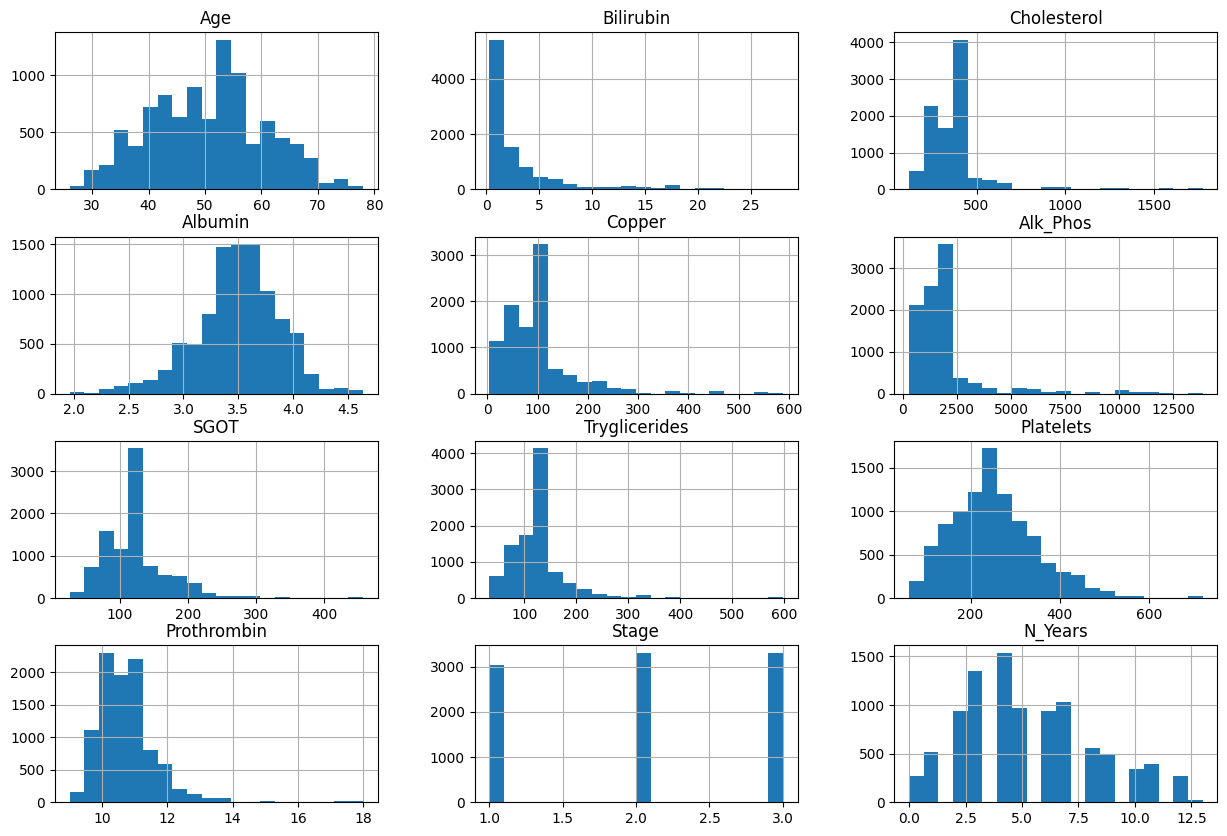

In [ ]:
df.hist(bins=20, figsize=(15,10))
plt.show()

**Before** **outliers**

* Boxplot analysis revealed the presence of significant outliers in multiple features.
* Outliers mainly in Bilirubin and enzyme levels.
* Indicates abnormal patient conditions.
* Outliers are present and may affect model performance.

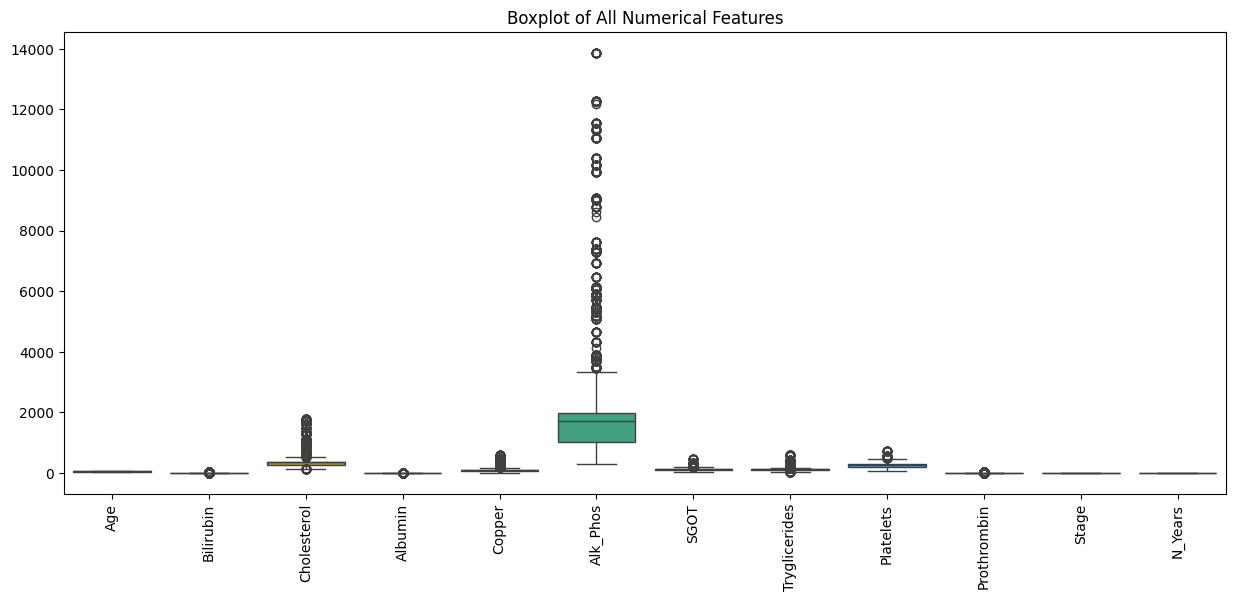

In [ ]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Boxplot of All Numerical Features")
plt.show()

**after removing outliers**
* After removing outliers, the data became more balanced and less skewed.
* Extreme values reduced.
* Distribution improved.
* Data quality improved after handling outliers.

In [ ]:
# Select only numerical columns
num_df = df.select_dtypes(include=np.number)

# Calculate IQR
Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

# Remove outliers
df_removed = df[~((num_df < (Q1 - 1.5 * IQR)) | (num_df > (Q3 + 1.5 * IQR))).any(axis=1)]

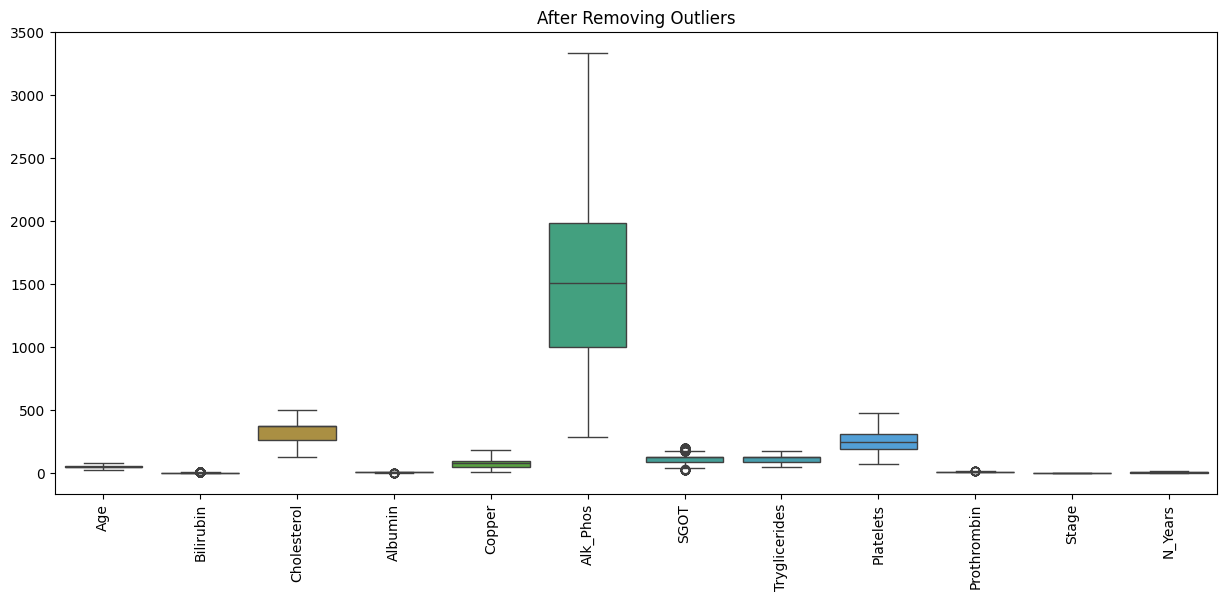

In [ ]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df_removed.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("After Removing Outliers")
plt.show()

**Categorical Analysis**

* Categorical features such as Gender and Target variable show imbalanced distribution.
* One class has more observations than the other.
* The dataset shows class imbalance.

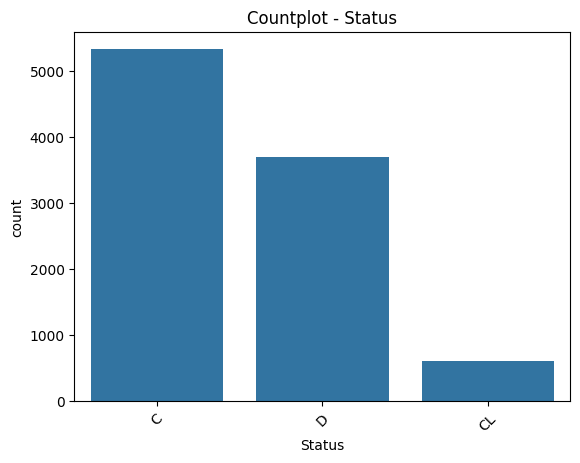

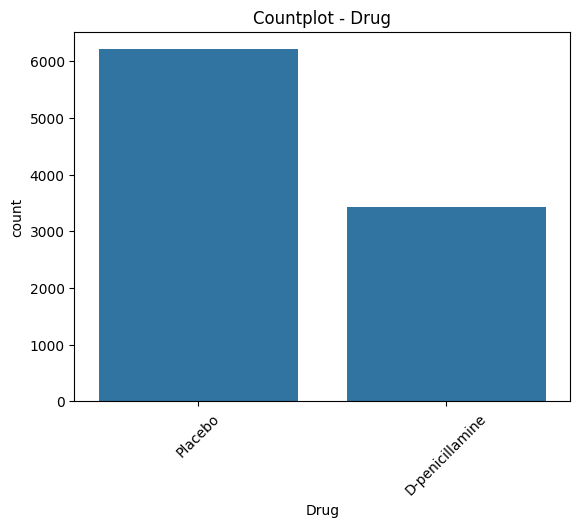

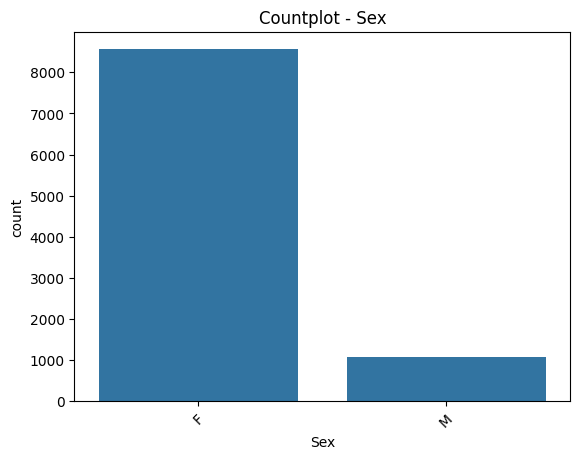

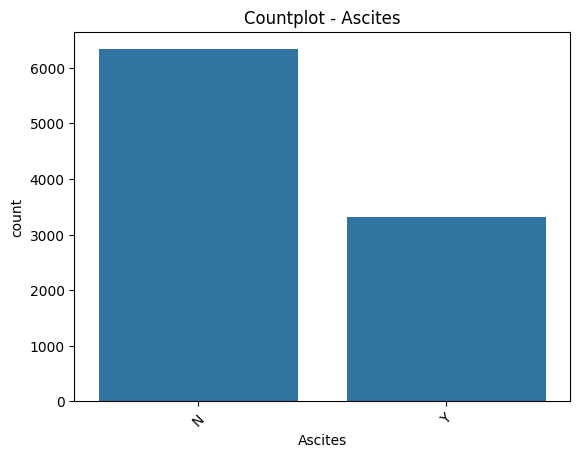

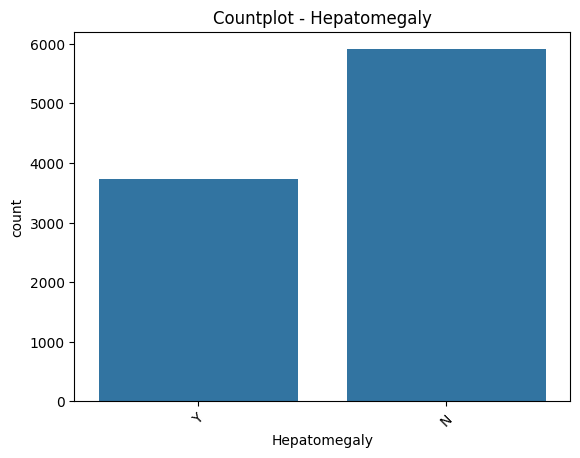

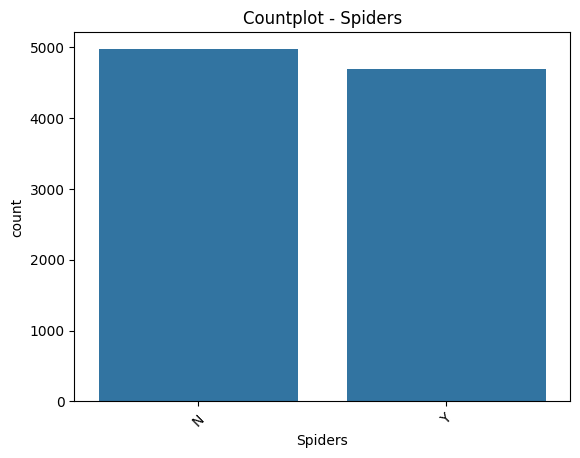

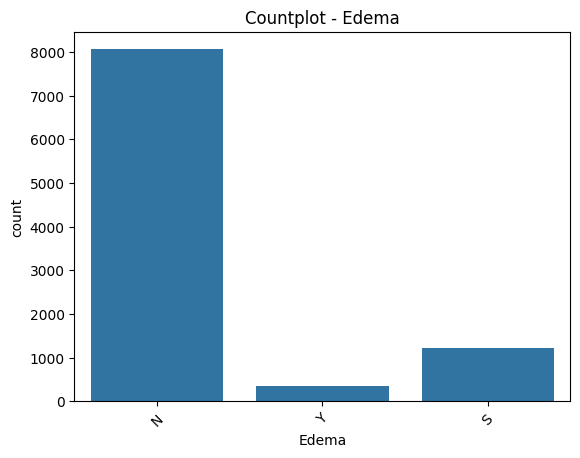

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(f"Countplot - {col}")
    plt.xticks(rotation=45)
    plt.show()

**Scatter** **plot**

* Bilirubin levels generally increase with disease severity (higher Stage / diseased patients).

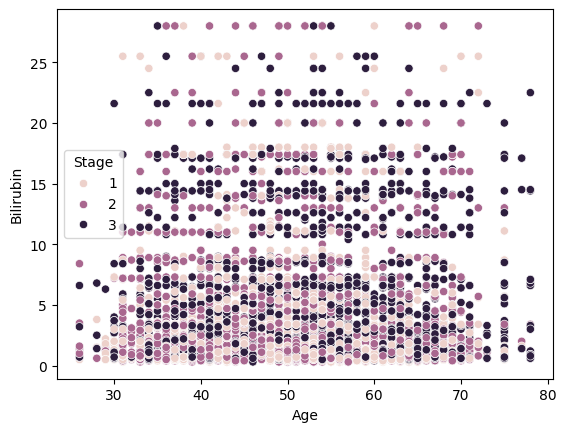

In [ ]:
sns.scatterplot(x='Age', y='Bilirubin', hue='Stage', data=df)
plt.show()

**Multivariate** **Analysis**

* pairplot analysis shows relationships between multiple features.
* Some features show separation between disease and non-disease.
* Feature combinations improve prediction.


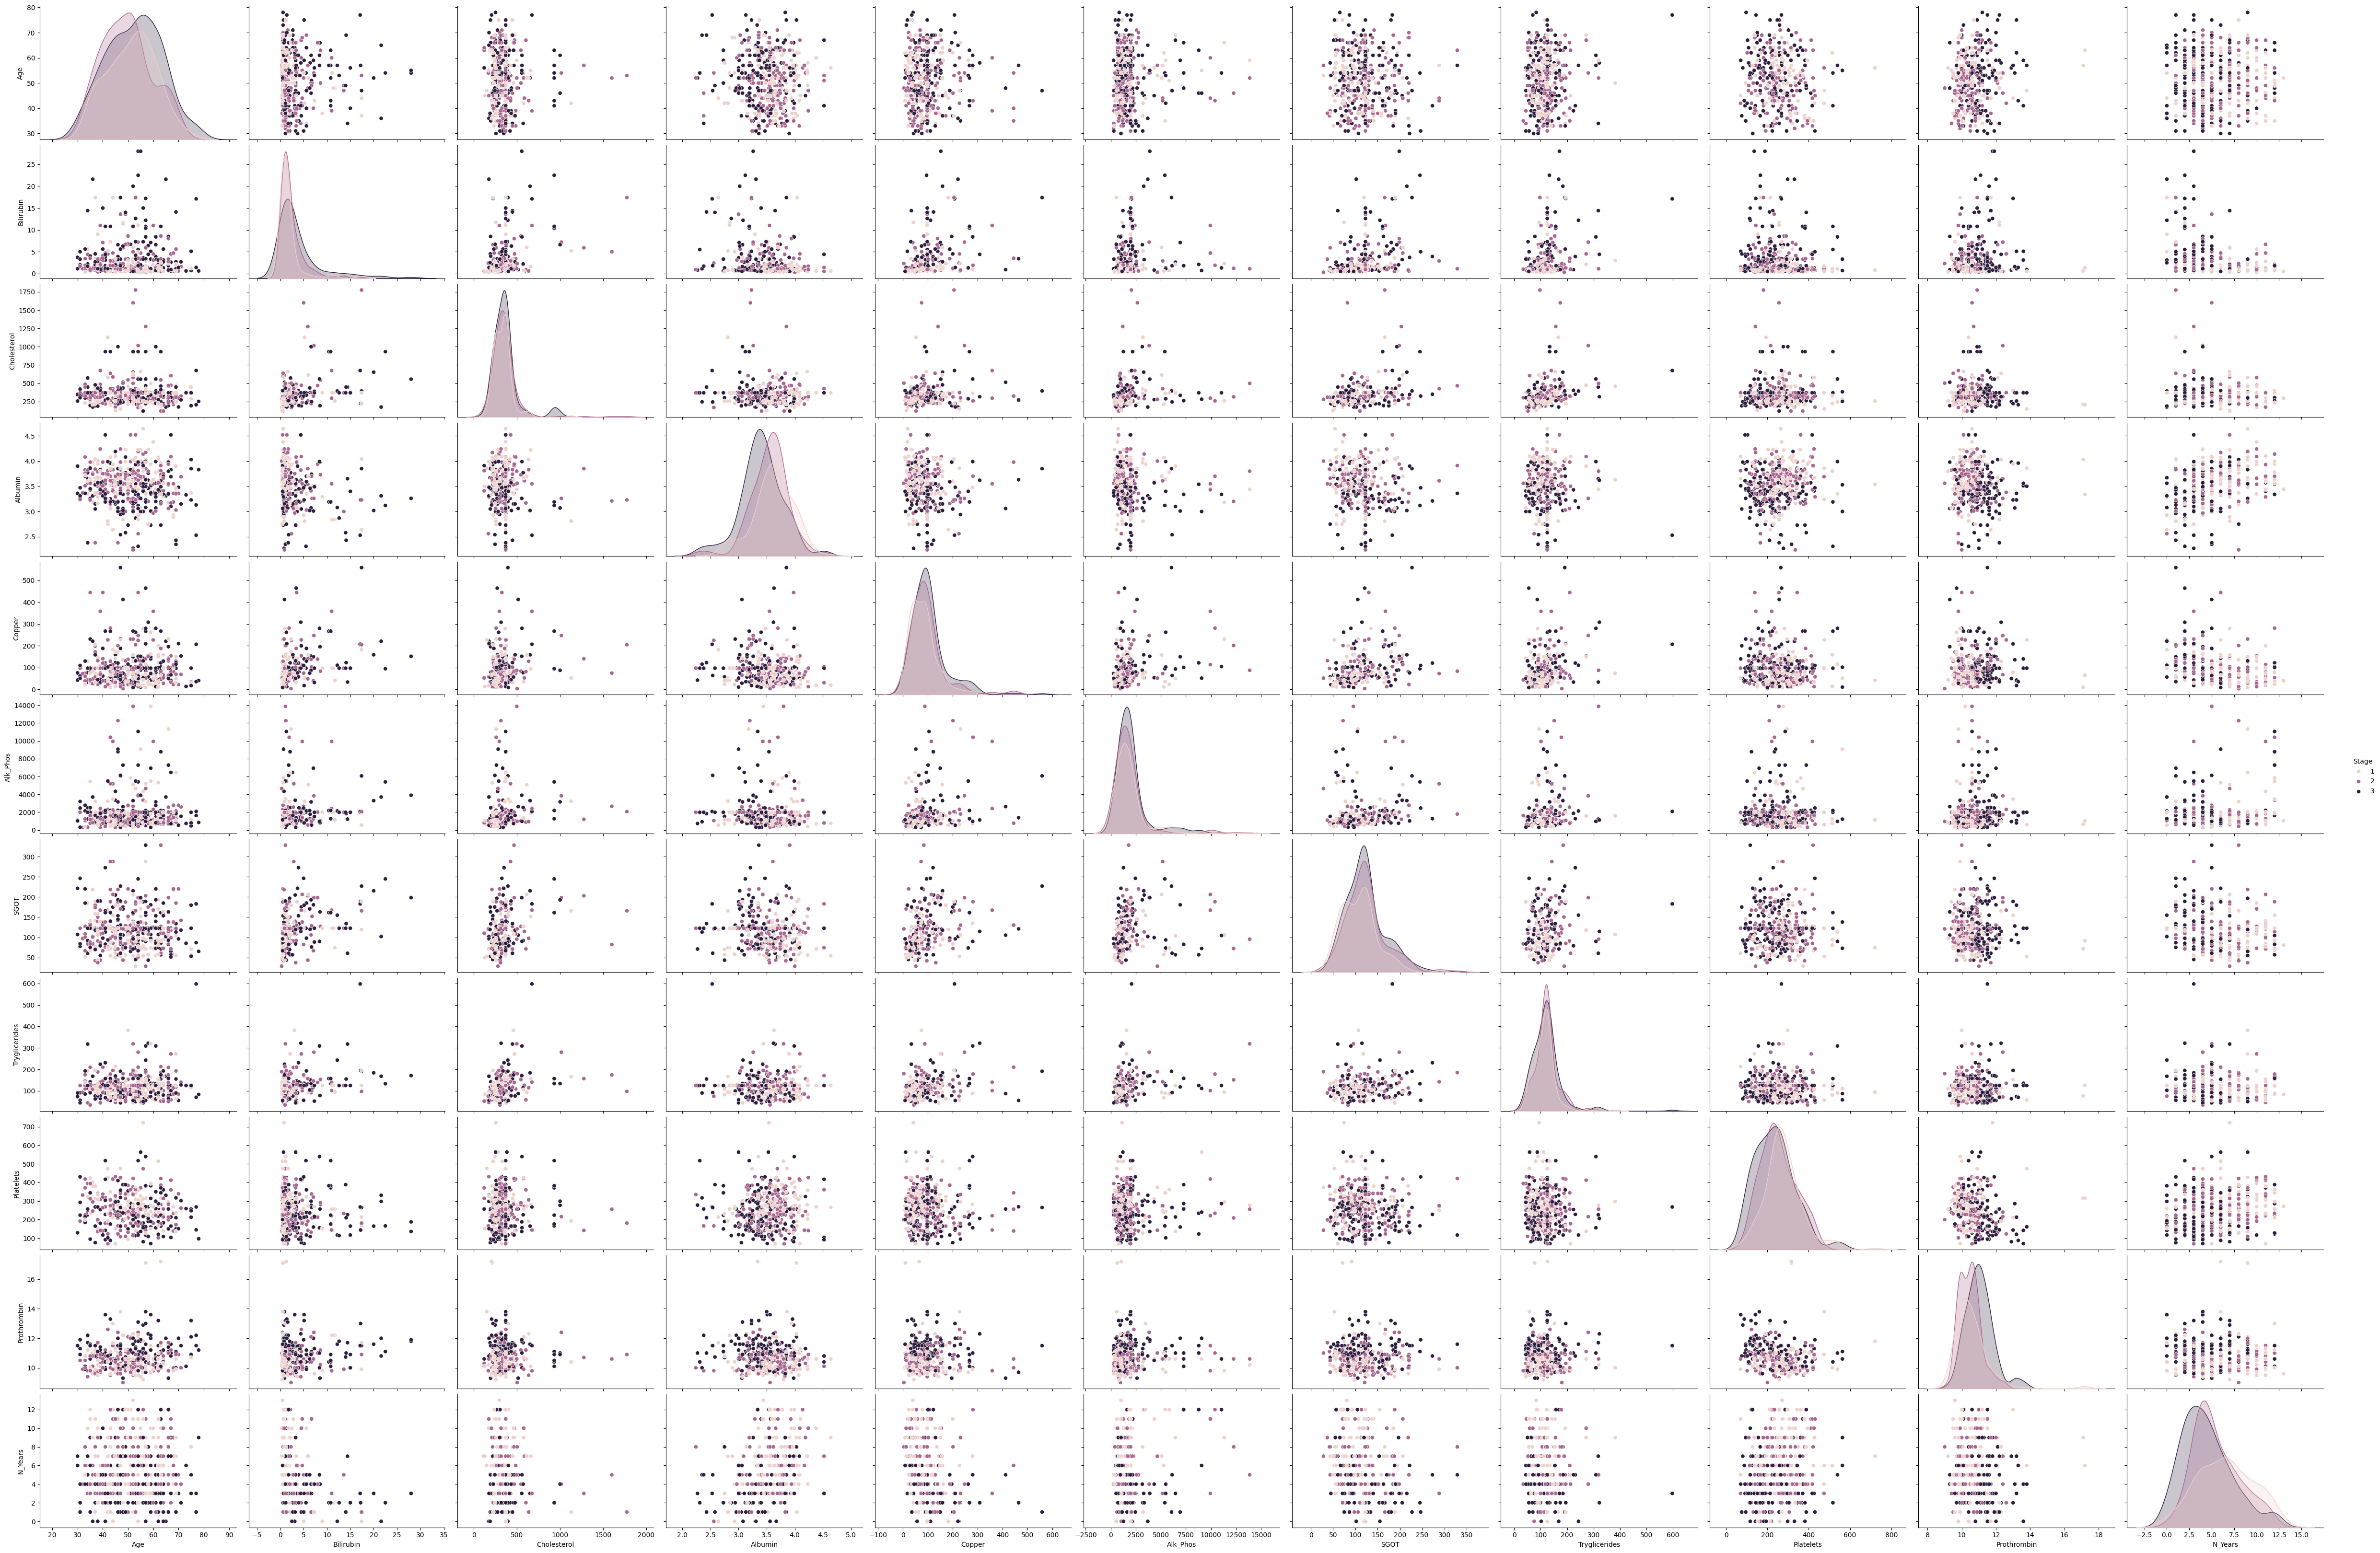

In [ ]:
sns.pairplot(df.sample(500), hue='Stage', height=3, aspect=1.5)
plt.show()

**Correlation** **Analysis**

* Correlation heatmap shows relationships between variables.
* SGPT and SGOT are strongly correlated.
* Most features have moderate correlation.

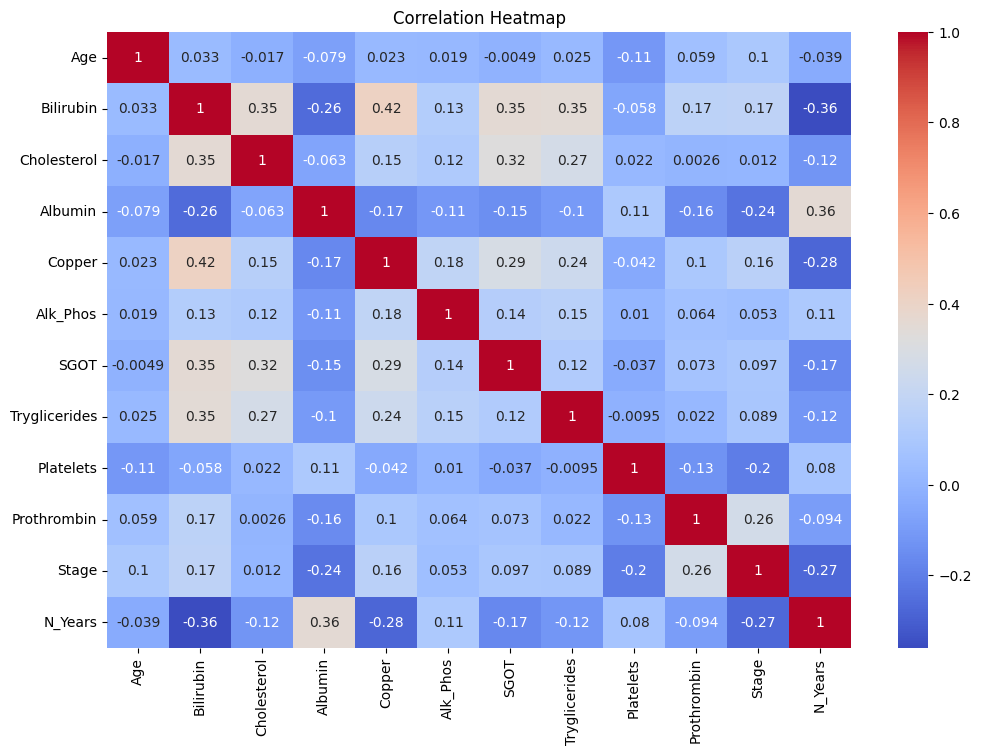

In [ ]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Target** **Variable** **Analysis**

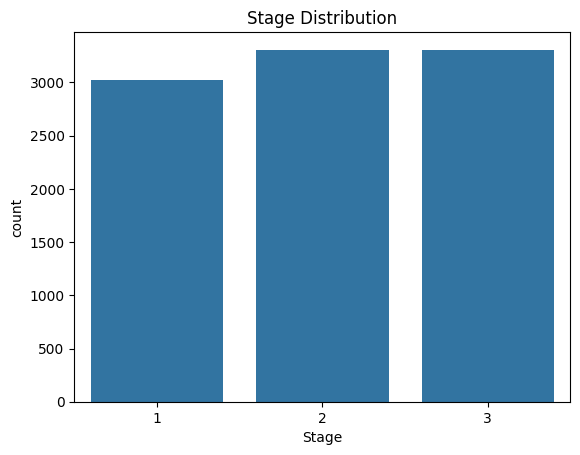

Stage
2    3308
3    3306
1    3025
Name: count, dtype: int64


In [ ]:
sns.countplot(x='Stage', data=df)
plt.title("Stage Distribution")
plt.show()

print(df['Stage'].value_counts())

**label** **Encodeing**

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

**Feature** **Selection**

In [ ]:
X = df.drop('Stage', axis=1)
y = df['Stage']


 **Split data**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7711, 18), (1928, 18), (7711,), (1928,))

**Feature** **Scaling**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**MODEL** **Building**

**Logistic** **regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
lr = LogisticRegression(max_iter=1000)
lr

LogisticRegression(max_iter=1000)

In [ ]:
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**Prediction**

In [ ]:
y_pred = lr.predict(X_test)


**model** **Evaluation**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5762448132780082


**Random** **Forest** **Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf

RandomForestClassifier()

In [ ]:
rf.fit(X_train, y_train)


RandomForestClassifier()

**prediction**

In [ ]:
y_pred_rf = rf.predict(X_test)


**Model** **Evaluation**

In [ ]:
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.8703319502074689


In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.87      0.86      0.86       617
           2       0.83      0.84      0.83       640
           3       0.91      0.91      0.91       671

    accuracy                           0.87      1928
   macro avg       0.87      0.87      0.87      1928
weighted avg       0.87      0.87      0.87      1928



**Confusion_matrix**

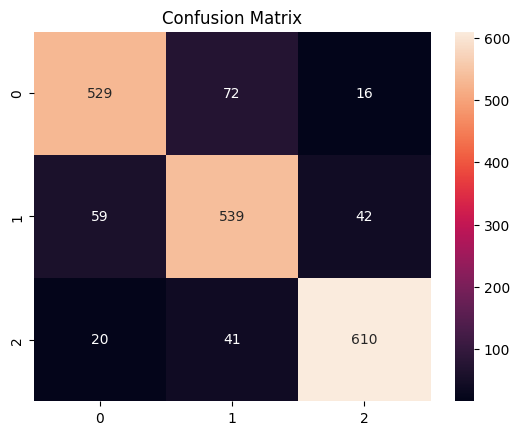

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

**Hyperparameters**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model = RandomForestClassifier()

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [ ]:
random = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 20],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42)

In [ ]:
print("Best Parameters:", random.best_params_)

Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': 20}


In [ ]:
best_model = random.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Final Accuracy: 0.8677385892116183
              precision    recall  f1-score   support

           1       0.87      0.85      0.86       617
           2       0.82      0.84      0.83       640
           3       0.91      0.91      0.91       671

    accuracy                           0.87      1928
   macro avg       0.87      0.87      0.87      1928
weighted avg       0.87      0.87      0.87      1928



In [ ]:
import joblib

model = joblib.dump(rf,"liver cirrhosis.model.pkl")

In [ ]:
from google.colab import files
files.download("liver cirrhosis.model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X.columns

Index(['Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders',
       'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos',
       'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'N_Years'],
      dtype='object')

In [ ]:
type(X.columns)

pandas.core.indexes.base.Index